# Problem 2

# 1. SETUP + DATA

DEVICE: cuda
train: (500, 2) sub: (500, 2)
total images on disk: 6000

train head:
  image_id  char
0  id_30U7  9610
1  id_5OK6  9041
2  id_EKC8  4202
3  id_GYIW  3201
4  id_213Y  1602


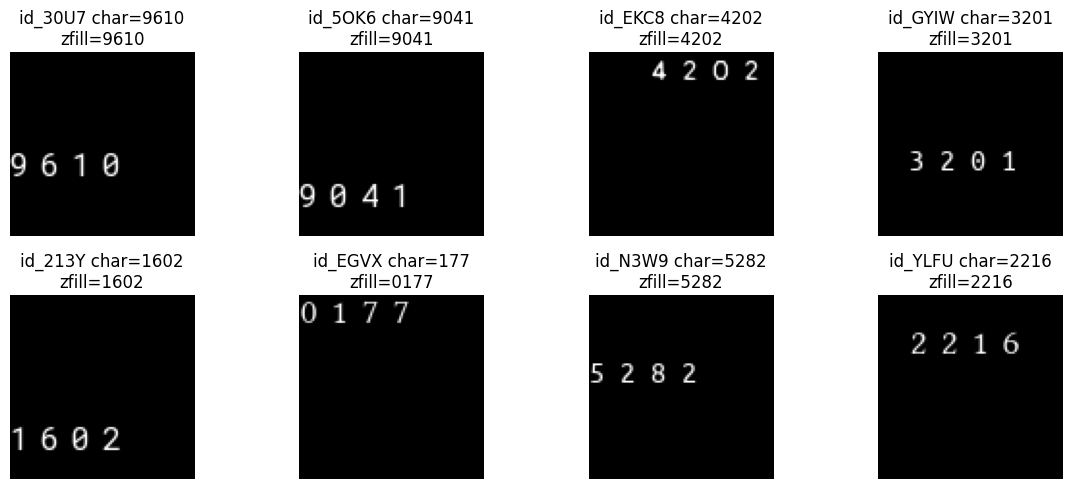

In [1]:
import os, time, random
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict, Counter

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED); torch.backends.cudnn.benchmark = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DATA_ROOT = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data"
IMG_DIR = f"{DATA_ROOT}/images"

train_df = pd.read_csv(f"{DATA_ROOT}/train.csv")
sub_df = pd.read_csv(f"{DATA_ROOT}/sample_submission.csv")
print("train:", train_df.shape, "sub:", sub_df.shape)
print("total images on disk:", len(os.listdir(IMG_DIR)))
print("\ntrain head:")
print(train_df.head())

# Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    row = train_df.iloc[i]
    img = Image.open(f"{IMG_DIR}/{row['image_id']}.png")
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{row['image_id']} char={row['char']}\nzfill={str(row['char']).zfill(4)}")
    ax.axis('off')
plt.tight_layout(); plt.show()

# 2. Ekstrak Angka

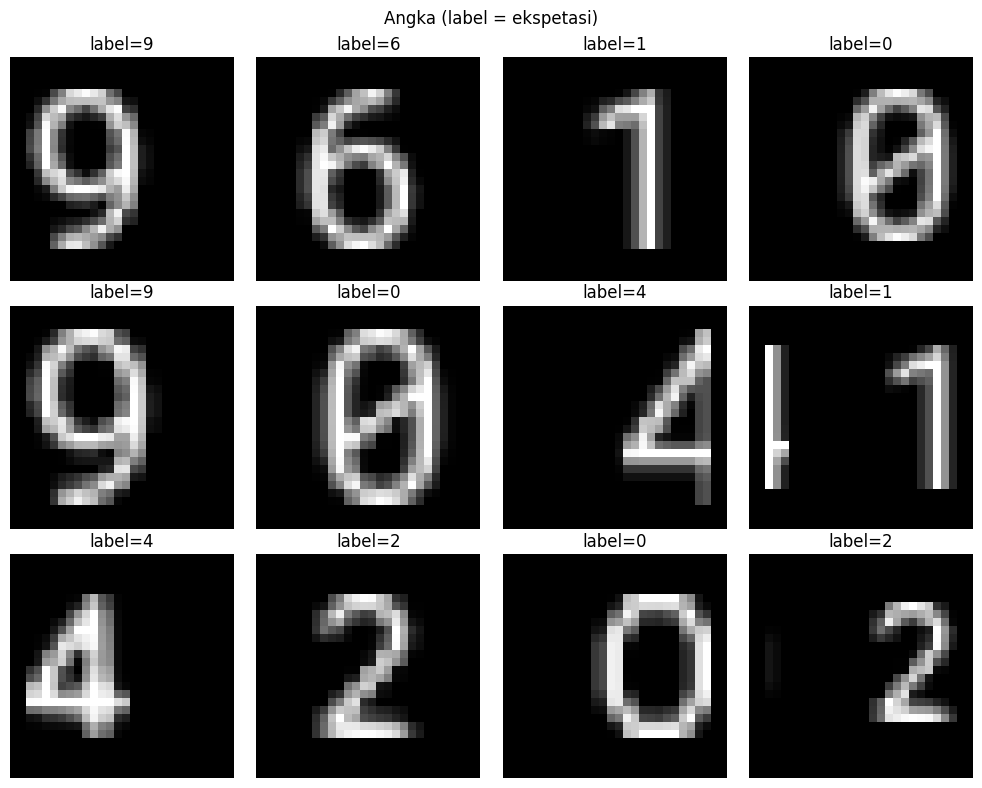

In [2]:
DIGIT_SIZE = 28

def extract_digits(image_id, img_dir=IMG_DIR):
    img = np.asarray(Image.open(f"{img_dir}/{image_id}.png").convert("L"))
    _, th = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(th)
    if coords is None:
        return [np.zeros((DIGIT_SIZE, DIGIT_SIZE), dtype=np.uint8)] * 4
    x, y, w, h = cv2.boundingRect(coords)
    crop = img[y:y+h, x:x+w]
    digit_w = w // 4
    digits = []
    for i in range(4):
        x0 = i * digit_w
        x1 = (i + 1) * digit_w if i < 3 else w
        d = crop[:, x0:x1]
        dh, dw = d.shape
        
        scale = (DIGIT_SIZE - 4) / max(dh, dw)
        new_h, new_w = max(1, int(dh * scale)), max(1, int(dw * scale))
        d_r = cv2.resize(d, (new_w, new_h), interpolation=cv2.INTER_AREA)
        canvas = np.zeros((DIGIT_SIZE, DIGIT_SIZE), dtype=np.uint8)
        oy = (DIGIT_SIZE - new_h) // 2
        ox = (DIGIT_SIZE - new_w) // 2
        canvas[oy:oy+new_h, ox:ox+new_w] = d_r
        digits.append(canvas)
    return digits

# --
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for r in range(3):
    row = train_df.iloc[r]
    digits = extract_digits(row["image_id"])
    char_str = str(row["char"]).zfill(4)
    for c in range(4):
        axes[r, c].imshow(digits[c], cmap='gray')
        axes[r, c].set_title(f"label={char_str[c]}")
        axes[r, c].axis('off')
plt.suptitle("Angka (label = ekspetasi)")
plt.tight_layout(); plt.show()

# 3. BUILD TRAINING SET

In [3]:
print("Angka:")
X_train, y_train = [], []
for _, row in train_df.iterrows():
    digits = extract_digits(row["image_id"])
    char_str = str(row["char"]).zfill(4)
    for d_img, d_label in zip(digits, char_str):
        X_train.append(d_img)
        y_train.append(int(d_label))
X_train = np.stack(X_train)
y_train = np.array(y_train)
print(f"  Bentuk: {X_train.shape}")
print(f"  per-kelas hitung: {np.bincount(y_train)}")

Angka:
  Bentuk: (2000, 28, 28)
  per-kelas hitung: [220 231 195 203 199 206 202 185 183 176]


# 4. DATASET + MODEL

In [4]:
class DigitDataset(Dataset):
    def __init__(self, X, y, train=True):
        self.X, self.y, self.train = X, y, train
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        img = self.X[i].astype(np.float32) / 255.0
        if self.train:
            angle = np.random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((DIGIT_SIZE/2, DIGIT_SIZE/2), angle, 1.0)
            tx, ty = np.random.uniform(-2, 2, 2)
            M[0, 2] += tx; M[1, 2] += ty
            img = cv2.warpAffine(img, M, (DIGIT_SIZE, DIGIT_SIZE), borderValue=0)
        img = (img - 0.5) / 0.5
        return torch.from_numpy(img).unsqueeze(0).float(), int(self.y[i])

class DigitCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),               # 14
            
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),               # 7
            
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),       # 1
        )
        self.fc = nn.Linear(128, n_classes)
    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.fc(x)

# train
n = len(X_train)

perm = np.random.permutation(n)

n_val = int(0.15 * n)

val_idx, tr_idx = perm[:n_val], perm[n_val:]

ds_tr = DigitDataset(X_train[tr_idx], y_train[tr_idx], train=True)
ds_va = DigitDataset(X_train[val_idx], y_train[val_idx], train=False)

loader_tr = DataLoader(ds_tr, batch_size=64, shuffle=True, num_workers=2)
loader_va = DataLoader(ds_va, batch_size=128, shuffle=False, num_workers=2)

print(f"train: {len(ds_tr)}  val: {len(ds_va)}")

train: 1700  val: 300


# TRAIN

In [5]:
EPOCHS = 30
LR = 1e-3

model = DigitCNN().to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

best_va = 0; best_state = None

for epoch in range(EPOCHS):
    model.train()
    tr_loss = 0; tr_n = 0; tr_c = 0
    for xb, yb in loader_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tr_loss += loss.item()*xb.size(0); tr_n += xb.size(0)
        tr_c += (logits.argmax(1) == yb).sum().item()
    sched.step()
    
    model.eval(); va_c = 0; va_n = 0
    
    with torch.no_grad():
        for xb, yb in loader_va:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            va_c += (model(xb).argmax(1) == yb).sum().item()
            va_n += xb.size(0)
            
    va_acc = va_c / va_n
    
    print(f"ep{epoch+1:2d}  tr_loss={tr_loss/tr_n:.4f}  tr_acc={tr_c/tr_n:.4f}  va_acc={va_acc:.4f}")
    if va_acc > best_va:
        best_va = va_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)

print(f"\nBest val acc: {best_va:.4f}")

ep 1  tr_loss=1.6527  tr_acc=0.6388  va_acc=0.5433
ep 2  tr_loss=0.7123  tr_acc=0.9653  va_acc=0.9867
ep 3  tr_loss=0.2863  tr_acc=0.9976  va_acc=1.0000
ep 4  tr_loss=0.1231  tr_acc=0.9994  va_acc=1.0000
ep 5  tr_loss=0.0690  tr_acc=0.9994  va_acc=1.0000
ep 6  tr_loss=0.0432  tr_acc=0.9994  va_acc=1.0000
ep 7  tr_loss=0.0289  tr_acc=1.0000  va_acc=1.0000
ep 8  tr_loss=0.0214  tr_acc=1.0000  va_acc=1.0000
ep 9  tr_loss=0.0179  tr_acc=1.0000  va_acc=1.0000
ep10  tr_loss=0.0159  tr_acc=1.0000  va_acc=1.0000
ep11  tr_loss=0.0132  tr_acc=1.0000  va_acc=1.0000
ep12  tr_loss=0.0108  tr_acc=1.0000  va_acc=1.0000
ep13  tr_loss=0.0096  tr_acc=1.0000  va_acc=1.0000
ep14  tr_loss=0.0082  tr_acc=1.0000  va_acc=1.0000
ep15  tr_loss=0.0077  tr_acc=1.0000  va_acc=1.0000
ep16  tr_loss=0.0072  tr_acc=1.0000  va_acc=1.0000
ep17  tr_loss=0.0071  tr_acc=1.0000  va_acc=1.0000
ep18  tr_loss=0.0066  tr_acc=1.0000  va_acc=1.0000
ep19  tr_loss=0.0056  tr_acc=1.0000  va_acc=1.0000
ep20  tr_loss=0.0054  tr_acc=1.

# PREDIK (semuanya)

In [6]:
print("Ekstrak digit")
all_files = sorted([f.replace(".png","") for f in os.listdir(IMG_DIR) if f.endswith(".png")])
all_digits = []
for sid in all_files:
    all_digits.extend(extract_digits(sid))
all_digits = np.stack(all_digits)
print(f"  shape: {all_digits.shape}")

print("Prediksi")
model.eval()
preds = []

with torch.no_grad():
    bs = 256
    for i in range(0, len(all_digits), bs):
        batch = all_digits[i:i+bs].astype(np.float32) / 255.0
        batch = (batch - 0.5) / 0.5
        x = torch.from_numpy(batch).unsqueeze(1).float().to(DEVICE)
        preds.append(model(x).argmax(1).cpu().numpy())
        
preds = np.concatenate(preds)

# --
chars = []
for i in range(0, len(preds), 4):
    char = int("".join(str(d) for d in preds[i:i+4]))
    chars.append(char)
chars = np.array(chars)
id_to_char = dict(zip(all_files, chars))

# Sanity Check
correct = sum(1 for _, r in train_df.iterrows() if id_to_char[r["image_id"]] == r["char"])
print(f"Train reconstruction accuracy: {correct}/{len(train_df)} = {correct/len(train_df):.4f}")
print(f"Unique chars predicted: {len(set(chars))} / {len(chars)} total")

Ekstrak digit
  shape: (24000, 28, 28)
Prediksi
Train reconstruction accuracy: 497/500 = 0.9940
Unique chars predicted: 3004 / 6000 total


# SUBMISI

In [7]:
char_to_ids = defaultdict(list)
for sid, c in id_to_char.items():
    char_to_ids[c].append(sid)

test_ids = sub_df["image_id"].tolist()
pair_ids = []
no_match = 0
for tid in test_ids:
    c = id_to_char[tid]
    candidates = [x for x in char_to_ids[c] if x != tid]
    if candidates:
        pair_ids.append(candidates[0])
    else:
        pair_ids.append("id_AAAA")
        no_match += 1

submission = pd.DataFrame({"image_id": test_ids, "image_pair": pair_ids})
submission.to_csv("submission.csv", index=False)

print(f"Matches found: {len(test_ids) - no_match}/{len(test_ids)}")
print(f"Self-pairs (should be 0): {(submission['image_id'] == submission['image_pair']).sum()}")
print(f"Unique pair_ids: {submission['image_pair'].nunique()}")
print("\npreview:")
print(submission.head(10))

Matches found: 500/500
Self-pairs (should be 0): 0
Unique pair_ids: 500

preview:
  image_id image_pair
0  id_DCBL    id_2C2B
1  id_YUKN    id_1IVX
2  id_25WM    id_QLGD
3  id_6ESM    id_QI2C
4  id_L51F    id_MNAV
5  id_S44P    id_XHCG
6  id_4UMK    id_D56R
7  id_WI08    id_HG9N
8  id_FPW6    id_9HKH
9  id_GA46    id_N2D7
